<a href="https://colab.research.google.com/github/aainabatool/IPKI-Machine-Learning-Course/blob/main/ML_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Libraries / Imports**

In [2]:
# Basic data + plotting
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML preprocessing + models + evaluation
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay

# saving
import joblib

# Optional (for model explainability)
# pip install shap   # run this once if shap not installed
import shap


## **1) Load dataset**

In [3]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv", encoding='latin1')
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **Quick data quality checks (duplicates, nulls, dtypes)**

In [4]:
print("Shape:", df.shape)
print("Duplicate rows:", df.duplicated().sum())
print("Missing values per column:\n", df.isnull().sum())
print("Data types:\n", df.dtypes)


Shape: (7043, 21)
Duplicate rows: 0
Missing values per column:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64
Data types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object


# **Remove duplicates**

In [5]:
df = df.drop_duplicates().reset_index(drop=True)


# **Fix data types / missing value**

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Count missing after conversion
print("Missing after conversion:\n", df['TotalCharges'].isnull().sum())

# If few missing, fill with median (ya drop if you prefer)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

Missing after conversion:
 11


/tmp/ipython-input-3492611657.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


# **Drop useless columns**

In [7]:
df = df.drop(columns=['customerID'])


# **Encode target and inspect class balance**

In [8]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})
print("Churn distribution:\n", df['Churn'].value_counts(normalize=True))


Churn distribution:
 Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


# **One-hot encoding for categorical features**

In [9]:
# Choose categorical cols (except target)
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns:", cat_cols)

# get_dummies (drop_first=True to avoid dummy trap)
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)


Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


# **Train-test split**

In [10]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# **Feature scaling (numeric features)**

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


# **Train a baseline model (Logistic Regression)**

In [12]:
model = LogisticRegression(max_iter=300)
model.fit(X_train_scaled, y_train)


LogisticRegression(max_iter=300)

# **Predict + Evaluate**

Confusion Matrix:
 [[925 110]
 [162 212]]

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC AUC: 0.8415846443979436


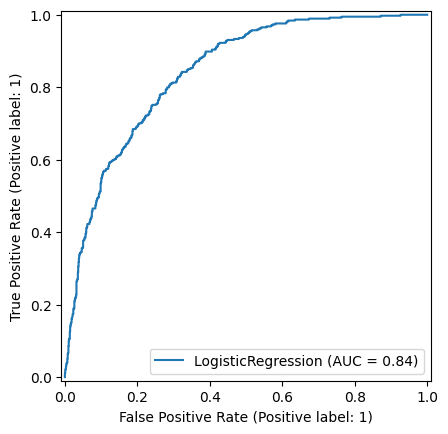

In [13]:
y_pred = model.predict(X_test_scaled)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ROC AUC
y_prob = model.predict_proba(X_test_scaled)[:,1]
print("ROC AUC:", roc_auc_score(y_test, y_prob))
RocCurveDisplay.from_estimator(model, X_test_scaled, y_test)
plt.show()


# **Improve: Cross-validation / GridSearch**

In [14]:
from sklearn.model_selection import GridSearchCV

params = {'C':[0.01,0.1,1,10]}
grid = GridSearchCV(LogisticRegression(max_iter=300), params, cv=5, scoring='f1')
grid.fit(X_train_scaled, y_train)
print("Best params:", grid.best_params_)
best_model = grid.best_estimator_


Best params: {'C': 10}


Use a stronger model — Random Forest

# **Use a stronger model — Random Forest**

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



# **Save model + scaler + feature list**

In [17]:
joblib.dump(rf, "churn_rf.joblib")
joblib.dump(scaler, "scaler.joblib")
joblib.dump(X.columns.tolist(), "feature_columns.joblib")


['feature_columns.joblib']